# First sample histograms

Load a GUNDAM engine and compare the model/data histogram contents for the first sample.

In [1]:
nCpuThreads = 3
gundamLibPath = "/Users/nadrino/Documents/Work/Install/gundam/lib"
workDir = "/Users/nadrino/Documents/Work/Output/results/gundam/GundamInputOA2024"
configPath = "configOA2024.yaml"
overrideList = [
    "override/v12ProdRun45.yaml",
    "override/onlyFlux.yaml",
    "override/noEigen.yaml",
]
dataType = "Toy"  # "Asimov", "Toy", or "RealData"
seed = 12345

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repoRoot = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
srcPath = repoRoot / "src"
if srcPath.exists() and str(srcPath) not in sys.path:
    sys.path.insert(0, str(srcPath))

from gundam_interface import GundamInterface, GundamLoader, GundamRuntime

In [3]:
np.random.seed(seed)

runtime = GundamRuntime(
    loader=GundamLoader(gundamLibPath=gundamLibPath),
    workDir=workDir,
    nCpuThreads=nCpuThreads,
    configPath=configPath,
    overrideList=overrideList,
    dataType=dataType,
    randomSeed=seed,
)

runtime.toDict(includeConfigJsonString=False)

{'nCpuThreads': 3,
 'workDir': '/Users/nadrino/Documents/Work/Output/results/gundam/GundamInputOA2024',
 'dataType': 'Toy',
 'loader': {'moduleName': 'GUNDAM',
  'gundamLibPath': '/Users/nadrino/Documents/Work/Install/gundam/lib'},
 'randomSeed': 12345,
 'configPath': 'configOA2024.yaml',
 'overrideList': ['override/v12ProdRun45.yaml',
  'override/onlyFlux.yaml',
  'override/noEigen.yaml']}

In [4]:
gundam = GundamInterface(runtime)
gundam.configure()
gundam.initialize()

2026.06.30 16:56:56  INFO ConfigUtils: Reading config file: /Users/nadrino/Documents/Work/Output/results/gundam/GundamInputOA2024/configOA2024.yaml
2026.06.30 16:56:56  INFO ConfigUtils: Overriding config with "/Users/nadrino/Documents/Work/Output/results/gundam/GundamInputOA2024/override/v12ProdRun45.yaml"
2026.06.30 16:56:56  WARN ConfigUtils:   Added: fitterEngineConfig/propagatorConfig/dataSetList/0(name:"ND280")/mc/filePathList
2026.06.30 16:56:56  WARN ConfigUtils:   Added: fitterEngineConfig/propagatorConfig/dataSetList/0(name:"ND280")/data/0(name:"data")/filePathList
2026.06.30 16:56:56  INFO ConfigUtils: Overriding config with "/Users/nadrino/Documents/Work/Output/results/gundam/GundamInputOA2024/override/onlyFlux.yaml"
2026.06.30 16:56:56  WARN ConfigUtils:   Override: fitterEngineConfig/propagatorConfig/parameterSetListConfig/0(name:"Flux Systematics")/isEnabled: true -> false
2026.06.30 16:56:56  WARN ConfigUtils:   Override: fitterEngineConfig/propagatorConfig/parameterSet

In [5]:
sampleIndex = 0

prefitModelSample = gundam.modelSamples[sampleIndex]
dataSample = gundam.dataSamples[sampleIndex]

sampleName = prefitModelSample.handle.getName()
prefitModelSumWeights = np.array(prefitModelSample.sumWeights, copy=True)
dataSumWeights = np.array(dataSample.sumWeights, copy=True)

print(f"Model bins: {prefitModelSumWeights.shape[0]}")
print(f"Data bins:  {dataSumWeights.shape[0]}")

Model bins: 252
Data bins:  252


In [6]:
bestFitLlh = gundam.minimize()
postfitModelSumWeights = np.array(gundam.modelSamples[sampleIndex].sumWeights, copy=True)

print(f"Best-fit LLH: {bestFitLlh:.8g}")


2026.06.30 16:56:59  INFO MinimizerBase: ──────────────────────────────
2026.06.30 16:56:59  INFO MinimizerBase: Summary of the fit parameters:
2026.06.30 16:56:59  INFO MinimizerBase: ──────────────────────────────
2026.06.30 16:56:59  INFO MinimizerBase: Flux Systematics: 100 parameters
┌───────┬──────────┬──────────┬──────────┬──────────────┬────────────────┐
│ Title │ Starting │    Prior │   StdDev │       Limits │         Status │
├───────┼──────────┼──────────┼──────────┼──────────────┼────────────────┤
│    #0 │ 1.000000 │ 1.000000 │ 0.059244 │ [-inf, +inf] │ Gaussian Prior │
│    #1 │ 1.000000 │ 1.000000 │ 0.052535 │ [-inf, +inf] │ Gaussian Prior │
│    #2 │ 1.000000 │ 1.000000 │ 0.052934 │ [-inf, +inf] │ Gaussian Prior │
│    #3 │ 1.000000 │ 1.000000 │ 0.051455 │ [-inf, +inf] │ Gaussian Prior │
│    #4 │ 1.000000 │ 1.000000 │ 0.073820 │ [-inf, +inf] │ Gaussian Prior │
│    #5 │ 1.000000 │ 1.000000 │ 0.087585 │ [-inf, +inf] │ Gaussian Prior │
│    #6 │ 1.000000 │ 1.000000 │ 0.

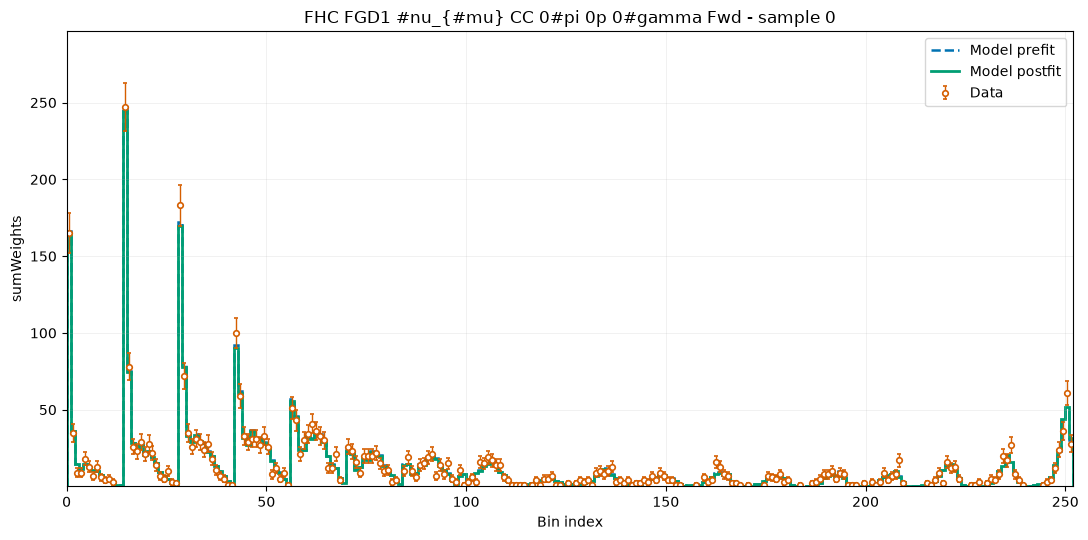

In [7]:
nBins = max(
    prefitModelSumWeights.shape[0],
    postfitModelSumWeights.shape[0],
    dataSumWeights.shape[0],
)
binEdges = np.arange(nBins + 1)
binCenters = binEdges[:-1] + 0.5

prefitPositive = np.pad(
    prefitModelSumWeights > 0,
    (0, nBins - prefitModelSumWeights.shape[0]),
)
postfitPositive = np.pad(
    postfitModelSumWeights > 0,
    (0, nBins - postfitModelSumWeights.shape[0]),
)
dataPositive = np.pad(dataSumWeights > 0, (0, nBins - dataSumWeights.shape[0]))
nonEmptyBins = np.flatnonzero(prefitPositive | postfitPositive | dataPositive)
dataMask = dataSumWeights > 0

fig, ax = plt.subplots(figsize=(11, 5.5))

prefitColor = "#0072B2"
postfitColor = "#009E73"
dataColor = "#D55E00"

ax.stairs(
    np.where(prefitModelSumWeights > 0, prefitModelSumWeights, np.nan),
    binEdges[: prefitModelSumWeights.shape[0] + 1],
    label="Model prefit",
    color=prefitColor,
    linewidth=1.8,
    linestyle="--",
)
ax.stairs(
    np.where(postfitModelSumWeights > 0, postfitModelSumWeights, np.nan),
    binEdges[: postfitModelSumWeights.shape[0] + 1],
    label="Model postfit",
    color=postfitColor,
    linewidth=2.0,
)
ax.errorbar(
    binCenters[: dataSumWeights.shape[0]][dataMask],
    dataSumWeights[dataMask],
    yerr=np.sqrt(dataSumWeights[dataMask]),
    fmt="o",
    color=dataColor,
    markerfacecolor="white",
    markeredgewidth=1.2,
    elinewidth=1.0,
    capsize=1.5,
    markersize=4,
    label="Data",
)

if nonEmptyBins.size:
    ax.set_xlim(max(0, nonEmptyBins.min() - 1), min(nBins, nonEmptyBins.max() + 2))

positiveValues = np.concatenate([
    prefitModelSumWeights[prefitModelSumWeights > 0],
    postfitModelSumWeights[postfitModelSumWeights > 0],
    dataSumWeights[dataSumWeights > 0],
])
if positiveValues.size:
    ax.set_ylim(positiveValues.min() * 0.1, positiveValues.max() * 1.2)

ax.set_xlabel("Bin index")
ax.set_ylabel("sumWeights")
ax.set_title(f"{sampleName} - sample {sampleIndex}")
ax.grid(alpha=0.25, which="both")
ax.legend()
fig.tight_layout()

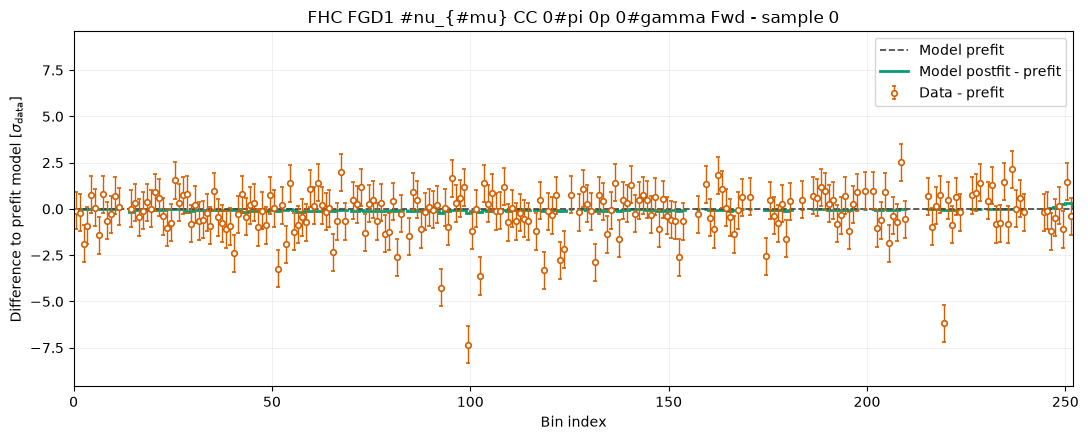

In [9]:
statError = np.sqrt(dataSumWeights)
validPullBins = statError > 0
pullBins = np.flatnonzero(validPullBins)

postfitPull = np.full(nBins, np.nan, dtype=float)
dataPull = np.full(nBins, np.nan, dtype=float)

postfitPull[validPullBins] = (
    (postfitModelSumWeights[validPullBins] - prefitModelSumWeights[validPullBins])
    / statError[validPullBins]
)
dataPull[validPullBins] = (
    (dataSumWeights[validPullBins] - prefitModelSumWeights[validPullBins])
    / statError[validPullBins]
)

fig, ax = plt.subplots(figsize=(11, 4.5))

ax.axhline(0.0, color="0.25", linewidth=1.2, linestyle="--", label="Model prefit")
ax.stairs(
    postfitPull,
    binEdges,
    label="Model postfit - prefit",
    color=postfitColor,
    linewidth=2.0,
)
ax.errorbar(
    binCenters[validPullBins],
    dataPull[validPullBins],
    yerr=np.ones(np.count_nonzero(validPullBins)),
    fmt="o",
    color=dataColor,
    markerfacecolor="white",
    markeredgewidth=1.2,
    elinewidth=1.0,
    capsize=1.5,
    markersize=4,
    label="Data - prefit",
)

if pullBins.size:
    ax.set_xlim(max(0, pullBins.min() - 1), min(nBins, pullBins.max() + 2))

finitePulls = np.concatenate([
    postfitPull[np.isfinite(postfitPull)],
    dataPull[validPullBins],
])
if finitePulls.size:
    span = max(np.max(np.abs(finitePulls)) + 1.0, 2.0)
    ax.set_ylim(-1.15 * span, 1.15 * span)

ax.set_xlabel("Bin index")
ax.set_ylabel(r"Difference to prefit model [$\sigma_\mathrm{data}$]")
ax.set_title(f"{sampleName} - sample {sampleIndex}")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()